# MIDI bGPT model validation

Loads the `MidiPatchy` dataset and the `MidiBGPT` / `MidiBGPTLoss` model, runs a forward
pass, checks loss & accuracy, and overfits one batch to confirm the loss decreases.

Config: `configs/midi-bgpt.yaml` · Data: `~/data/midi/patches/midi-test202606.midi-notagen.pt`

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel

DATA_DIR = str(Path.home() / 'data' / 'midi' / 'patches')
CONFIG = str(REPO_ROOT / 'configs' / 'midi-bgpt.yaml')
print('repo:', REPO_ROOT)
print('data dir:', DATA_DIR)

repo: /home/camus/work/deep-starry
data dir: /home/camus/data/midi/patches


In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)
config['data.batch_size'] = 2
config['trainer.device'] = 'cpu'
# smaller model + window keep this validation quick on CPU
config['data.args.patch_length'] = 256
config['model.args.hidden_size'] = 128
config['model.args.patch_num_layers'] = 2
config['model.args.token_num_layers'] = 2
config['model.args.n_head'] = 4

train, val = loadDataset(config, data_dir=DATA_DIR, device='cpu')
print('train items:', len(train.dataset), 'val items:', len(val.dataset))

batch = next(iter(train))
print('batch keys:', list(batch.keys()))
print('input_patches:', tuple(batch['input_patches'].shape), batch['input_patches'].dtype)
print('input_masks:  ', tuple(batch['input_masks'].shape), batch['input_masks'].dtype)
print('input_targets:', tuple(batch['input_targets'].shape), batch['input_targets'].dtype)
print('max token id:', int(batch['input_patches'].max()), '/ token_vocab_size', config['model.args.token_vocab_size'])
print('real patches per item:', batch['input_masks'].sum(dim=1).tolist())
print('target patches per item:', batch['input_targets'].sum(dim=1).tolist())

train items: 456 val items: 50
batch keys: ['input_patches', 'input_masks', 'input_targets']
input_patches: (2, 256, 16) torch.int64
input_masks:   (2, 256) torch.int64
input_targets: (2, 256) torch.int64
max token id: 35 / token_vocab_size 37
real patches per item: [256, 256]
target patches per item: [255, 255]


In [3]:
# Inference model (deducer) and Loss model (training wrapper), built via the factory.
deducer = loadModel(config['model'], imports=config['imports'])
model = loadModel(config['model'], postfix='Loss', imports=config['imports'])
print('deducer:', type(deducer).__name__, '| loss model:', type(model).__name__)

n_params = sum(p.numel() for p in model.deducer.parameters())
print('MidiBGPT params: %.2fM' % (n_params / 2**20))
print('base type:        ', model.deducer.base_type)
print('patch-level layers:', model.deducer.patch_level_decoder.base.config.num_hidden_layers)
print('token-level layers:', model.deducer.token_level_decoder.base.config.num_hidden_layers)
print('token vocab size:  ', model.deducer.token_vocab_size)

deducer: MidiBGPT | loss model: MidiBGPTLoss
MidiBGPT params: 1.09M
base type:         gpt2
patch-level layers: 2
token-level layers: 2
token vocab size:   37


In [4]:
# Single forward pass: loss (scalar Tensor) + metric (dict)
model.train()
loss, metric = model(batch)
print('loss:', loss.item())
print('metric:', metric)
assert loss.requires_grad and loss.dim() == 0

# inspectRun gives a detail dict (used by validators)
model.eval()
with torch.no_grad():
    insp = model.inspectRun(batch)
print('inspect:', {k: (v if not torch.is_tensor(v) else tuple(v.shape)) for k, v in insp.items()})

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


loss: 3.62766170501709
metric: {'acc': 0.013704589568078518, 'err': 0.9862954104319215}
inspect: {'loss': 3.6289594173431396, 'acc': 0.012181857600808144, 'err': 0.9878181423991919, 'time_err': 0.9621621631085873, 'logits': (510, 17, 37), 'target_patches': (510, 16), 'n_patches': 510}


In [5]:
# A few training steps on one batch should drive the loss down (overfit sanity check).
model.train()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
history = []
for step in range(20):
    opt.zero_grad()
    loss, metric = model(batch)
    loss.backward()
    opt.step()
    history.append((loss.item(), metric['acc']))
    if step % 5 == 0 or step == 19:
        print(f'step {step:02d}  loss={loss.item():.4f}  acc={metric["acc"]:.4f}')

print('\nloss start -> end:', round(history[0][0], 4), '->', round(history[-1][0], 4))
print('acc  start -> end:', round(history[0][1], 4), '->', round(history[-1][1], 4))
assert history[-1][0] < history[0][0], 'loss did not decrease'

step 00  loss=3.6310  acc=0.0128


step 05  loss=2.1685  acc=0.5380


step 10  loss=1.8148  acc=0.5658


step 15  loss=1.5903  acc=0.5965


step 19  loss=1.4461  acc=0.6032

loss start -> end: 3.631 -> 1.4461
acc  start -> end: 0.0128 -> 0.6032


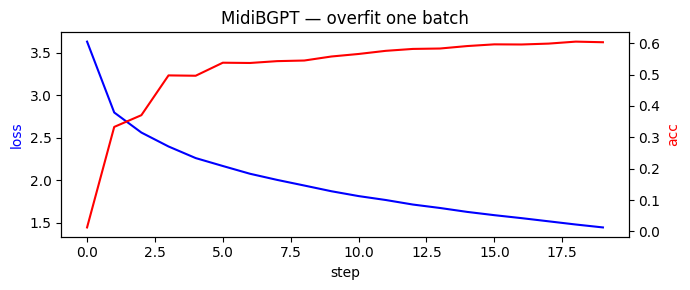

In [6]:
# Loss / accuracy curve over the overfit steps.
# Force the inline backend: .env.local may set a GUI backend (MPLBACKEND=TkAgg),
# which renders nothing under headless/nbconvert execution.
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt

losses = [h[0] for h in history]
accs = [h[1] for h in history]
fig, ax1 = plt.subplots(figsize=(7, 3))
ax1.plot(losses, 'b-', label='loss'); ax1.set_ylabel('loss', color='b'); ax1.set_xlabel('step')
ax2 = ax1.twinx(); ax2.plot(accs, 'r-', label='acc'); ax2.set_ylabel('acc', color='r')
plt.title('MidiBGPT — overfit one batch'); plt.tight_layout(); plt.show()